In [4]:
# Wint Wah Kyaw Soe
# YKPT-22314 (Section A | SE | E003)
# IS-212
# Practical Assignment III (Project)
# Supervisor - Dr. Hsu Myat Mo
# Phising Detection and Anomaly URL Detection Project

In [2]:
# import
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# finding dataset size
df = pd.read_csv('phishing_website_full.csv')

print("My Phishing Dataset Size Summary")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Total Cells: {df.size:,}")

My Phishing Dataset Size Summary
Rows: 9,999
Columns: 112
Total Cells: 1,119,888


In [5]:
# analyzing data type
summary_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Null Count': df.isnull().sum(),
    'Null Ratio (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique(),
    'Sample Value': df.iloc[0] if len(df) > 0 else None
})

print("DATA TYPES & SUMMARY")
print(summary_df)

print("\n DATA HEAD (First 3 rows)")
print(df.head(3))

DATA TYPES & SUMMARY
                     Data Type  Non-Null Count  Null Count  Null Ratio (%)  \
qty_dot_url              int64            9999           0             0.0   
qty_hyphen_url           int64            9999           0             0.0   
qty_underline_url        int64            9999           0             0.0   
qty_slash_url            int64            9999           0             0.0   
qty_questionmark_url     int64            9999           0             0.0   
...                        ...             ...         ...             ...   
qty_redirects            int64            9999           0             0.0   
url_google_index         int64            9999           0             0.0   
domain_google_index      int64            9999           0             0.0   
url_shortened            int64            9999           0             0.0   
phishing                 int64            9999           0             0.0   

                      Unique Values  Sampl

In [6]:
# checking null values
standard_nulls = df.isna().sum()
minus_ones = (df == -1).sum()

missing_summary = pd.DataFrame({
    'Standard NaNs': standard_nulls,
    'Encoded (-1)': minus_ones,
    'Total Missing': standard_nulls + minus_ones,
    'Missing Ratio (%)': ((standard_nulls + minus_ones) / len(df) * 100).round(2)
})

cols_with_missing = missing_summary[missing_summary['Total Missing'] > 0]

print("Overall dataset check for null values")
print(f"• Total Rows in Dataset: {len(df):,}")
print(f"• Total Standard NaNs (Nulls): {standard_nulls.sum()}")
print(f"• Total Encoded (-1) Values: {minus_ones.sum():,}")

if len(cols_with_missing) > 0:
    print(f"\n COLUMNS WITH MISSING / -1 VALUES ({len(cols_with_missing)} Columns Found)")
    print(cols_with_missing.sort_values(by='Total Missing', ascending=False))
else:
    print("\n there is no missing values or null values in the dataset.")

Overall dataset check for null values
• Total Rows in Dataset: 9,999
• Total Standard NaNs (Nulls): 0
• Total Encoded (-1) Values: 384,183

 COLUMNS WITH MISSING / -1 VALUES (66 Columns Found)
                      Standard NaNs  Encoded (-1)  Total Missing  \
qty_and_params                    0          9158           9158   
qty_space_params                  0          9158           9158   
qty_dot_params                    0          9158           9158   
qty_hyphen_params                 0          9158           9158   
qty_underline_params              0          9158           9158   
...                             ...           ...            ...   
time_response                     0           662            662   
qty_ip_resolved                   0           533            533   
ttl_hostname                      0           531            531   
url_google_index                  0             9              9   
domain_google_index               0             9          

In [7]:
# analyzing dataset distribution
features = df.drop(columns=['phishing'], errors='ignore')

dist_summary = []

for col in features.columns:

    clean_data = features[col][features[col] != -1]

    if clean_data.nunique() <= 2 or len(clean_data) < 8:
        continue

    skewness = clean_data.skew()
    _, p_val = stats.normaltest(clean_data)

    if p_val > 0.05:
        dist_type = "Normal Distribution"
    elif skewness > 1:
        dist_type = "Highly Right-Skewed"
    elif skewness < -1:
        dist_type = "Highly Left-Skewed"
    elif 0.5 < abs(skewness) <= 1:
        dist_type = "Moderately Skewed"
    else:
        dist_type = "Non-Normal (Symmetric)"

    dist_summary.append({
        'Column': col,
        'Skewness': round(skewness, 2),
        'p-value': round(p_val, 5),
        'Distribution Summary': dist_type
    })

distribution_df = pd.DataFrame(dist_summary)
print(distribution_df)

                  Column  Skewness  p-value Distribution Summary
0            qty_dot_url      5.34      0.0  Highly Right-Skewed
1         qty_hyphen_url      7.13      0.0  Highly Right-Skewed
2      qty_underline_url     13.82      0.0  Highly Right-Skewed
3          qty_slash_url      1.98      0.0  Highly Right-Skewed
4   qty_questionmark_url     14.51      0.0  Highly Right-Skewed
..                   ...       ...      ...                  ...
64       qty_ip_resolved      4.04      0.0  Highly Right-Skewed
65       qty_nameservers      2.20      0.0  Highly Right-Skewed
66        qty_mx_servers      1.69      0.0  Highly Right-Skewed
67          ttl_hostname     18.94      0.0  Highly Right-Skewed
68         qty_redirects      2.63      0.0  Highly Right-Skewed

[69 rows x 4 columns]


/var/folders/bx/htpb7gg97s932r5q5ftp2wbr0000gn/T/ipykernel_29392/3294018737.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


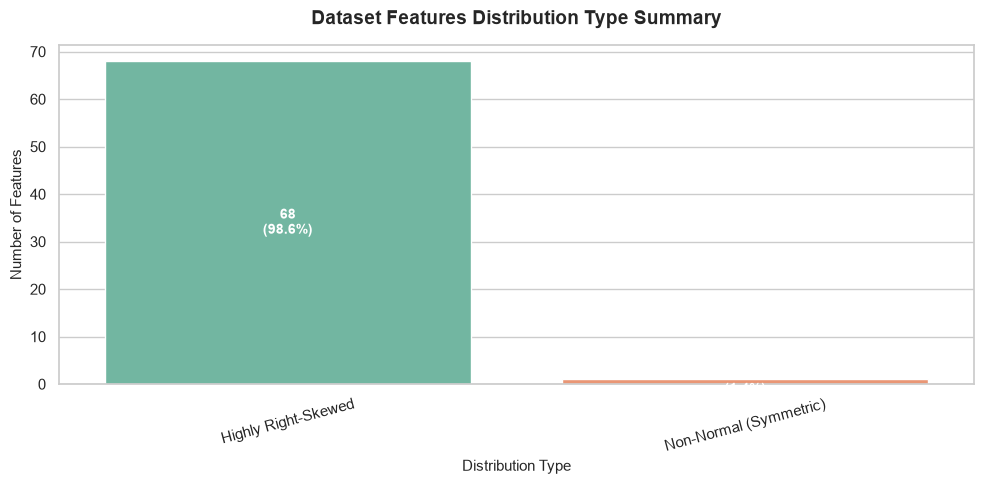

In [8]:
# distribution graph 
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=distribution_df,
    x='Distribution Summary',
    palette='Set2',
    order=distribution_df['Distribution Summary'].value_counts().index
)

total = len(distribution_df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{(height/total)*100:.1f}%'
    ax.annotate(f'{int(height)}\n({percentage})',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=10, color='white', weight='bold')

plt.title('Dataset Features Distribution Type Summary', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Distribution Type', fontsize=11)
plt.ylabel('Number of Features', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [9]:
# checking noise values
exact_duplicates = df.duplicated().sum()

X = df.drop(columns=['phishing'], errors='ignore')
feature_duplicates = df[X.duplicated(keep=False)]
if len(feature_duplicates) > 0:
    grouped = feature_duplicates.groupby(list(X.columns))['phishing'].nunique()
    contradictory_count = (grouped > 1).sum()
else:
    contradictory_count = 0

invalid_negatives = (X < -1).sum().sum()

quasi_constant_cols = []
for col in X.columns:
    top_value_pct = X[col].value_counts(normalize=True).iloc[0]
    if top_value_pct >= 0.99:
        quasi_constant_cols.append((col, round(top_value_pct * 100, 2)))

print("Noise data check report")
print(f"• Exact Duplicate Rows: {exact_duplicates} rows")
print(f"• Contradictory Duplicates: {contradictory_count} instances")
print(f"• Invalid Values: {invalid_negatives} occurrences")
print(f"• Quasi-Constant Features: {len(quasi_constant_cols)} columns")

if quasi_constant_cols:
    print("\nQUASI-CONSTANT COLUMNS LIST ")
    for col, pct in quasi_constant_cols:
        print(f" - {col}: {pct}% identical value")

Noise data check report
• Exact Duplicate Rows: 55 rows
• Contradictory Duplicates: 0 instances
• Invalid Values: 0 occurrences
• Quasi-Constant Features: 29 columns

QUASI-CONSTANT COLUMNS LIST 
 - qty_questionmark_url: 99.3% identical value
 - qty_exclamation_url: 99.83% identical value
 - qty_space_url: 99.95% identical value
 - qty_tilde_url: 99.77% identical value
 - qty_comma_url: 99.82% identical value
 - qty_plus_url: 99.86% identical value
 - qty_asterisk_url: 99.96% identical value
 - qty_hashtag_url: 100.0% identical value
 - qty_dollar_url: 99.94% identical value
 - qty_underline_domain: 99.92% identical value
 - qty_slash_domain: 100.0% identical value
 - qty_questionmark_domain: 100.0% identical value
 - qty_equal_domain: 100.0% identical value
 - qty_at_domain: 100.0% identical value
 - qty_and_domain: 100.0% identical value
 - qty_exclamation_domain: 100.0% identical value
 - qty_space_domain: 100.0% identical value
 - qty_tilde_domain: 100.0% identical value
 - qty_com